# Stage 1 – λ=50/100 comparison (seasonal vs battery‑equivalent)


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Runs to compare (use folder names)
RUNS = [
    "stagel_3month_lamba_2_seasonal_2year",
    "stagel_3month_lamba_1.25_seasonal_2years",
]

# Optional: override labels (defaults to run string)
LABELS = {
    "stagel_3month_lamba_2_seasonal_2year": "lambda2_seasonal_2y",
    "stagel_3month_lamba_1.25_seasonal_2years": "lambda1.25_seasonal_2y",
}

# Years to include
YEARS = [1985, 1986]

output_root = Path("acorn-julia/runs/low_RE_mod_elec_iter0/outputs/historical_1980_2019")
if not output_root.exists():
    output_root = Path.cwd().parent / "outputs" / "historical_1980_2019"

print("Runs:", RUNS)
print("Years:", YEARS)
print("output_root:", output_root)


Runs: ['stagel_3month_lamba_2_seasonal_2year', 'stagel_3month_lamba_1.25_seasonal_2years']
Years: [1985, 1986]
output_root: /home/fs01/jl2966/acorn-julia2/acorn-julia/runs/low_RE_mod_elec_iter0/outputs/historical_1980_2019


In [2]:
# --- Helpers ----------------------------------------------------------------

def _strip_tz(idx):
    if hasattr(idx, 'tz') and idx.tz is not None:
        return idx.tz_convert(None)
    return idx


def _empty_tidy(value_name: str, extra_cols=None) -> pd.DataFrame:
    extra_cols = extra_cols or []
    data = {c: pd.Series(dtype=float) for c in extra_cols + [value_name]}
    data["timestamp"] = pd.to_datetime([])
    return pd.DataFrame(data)


def tidy_storage_df(df: pd.DataFrame, value_name: str) -> pd.DataFrame:
    meta_cols = [c for c in ["bus_id", "asset_type", "zone", "is_seasonal"] if c in df.columns]
    value_cols = [c for c in df.columns if c not in meta_cols]
    tidy = df.melt(id_vars=meta_cols, value_vars=value_cols,
                   var_name="timestamp", value_name=value_name)
    tidy["timestamp"] = pd.to_datetime(tidy["timestamp"], errors="coerce")
    tidy = tidy.dropna(subset=["timestamp"])
    tidy[value_name] = pd.to_numeric(tidy[value_name], errors="coerce").fillna(0.0)
    return tidy


def tidy_storage_path(path: Path, value_name: str) -> pd.DataFrame:
    if not path.exists():
        return _empty_tidy(value_name)
    return tidy_storage_df(pd.read_csv(path), value_name)


def tidy_bus_df(path: Path, value_name: str) -> pd.DataFrame:
    if not path.exists():
        return _empty_tidy(value_name, extra_cols=["bus_id"])
    df = pd.read_csv(path)
    meta_cols = [c for c in ["bus_id", "zone"] if c in df.columns]
    value_cols = [c for c in df.columns if c not in meta_cols]
    tidy = df.melt(id_vars=meta_cols, value_vars=value_cols,
                   var_name="timestamp", value_name=value_name)
    tidy["timestamp"] = pd.to_datetime(tidy["timestamp"], errors="coerce")
    tidy = tidy.dropna(subset=["timestamp"])
    tidy[value_name] = pd.to_numeric(tidy[value_name], errors="coerce").fillna(0.0)
    return tidy


def total_ts(df: pd.DataFrame, value_name: str) -> pd.Series:
    if df is None or df.empty:
        return pd.Series(dtype=float)
    return df.groupby("timestamp")[value_name].sum()


def load_seasonal_soc(run_dir: Path, year: int) -> pd.Series:
    p = run_dir / f"storage_state_seasonal_{year}.csv"
    if not p.exists():
        return pd.Series(dtype=float)
    df = pd.read_csv(p)
    if df.empty:
        return pd.Series(dtype=float)
    cols = [c for c in df.columns if c not in ("zone",)]
    df = df[cols]
    if not df.empty and df.iloc[0, 0] == "bus_id":
        df = df.iloc[1:]
    value_cols = [c for c in df.columns if c != "bus_id"]
    df[value_cols] = df[value_cols].apply(pd.to_numeric, errors="coerce")
    soc = df[value_cols].sum(axis=0)
    soc.index = pd.to_datetime(soc.index, errors="coerce")
    soc = soc.dropna()
    if hasattr(soc.index, 'tz') and soc.index.tz is not None:
        soc.index = soc.index.tz_convert(None)
    return soc


def safe_sum(series: pd.Series) -> float:
    return pd.to_numeric(series, errors="coerce").fillna(0.0).sum()


def detect_years(run_dir: Path) -> list[int]:
    years = set()
    patterns = ["charge_base_*.csv", "load_shedding_*.csv", "charge_seasonal_*.csv"]
    for pat in patterns:
        for p in run_dir.glob(pat):
            try:
                years.add(int(p.stem.split("_")[-1]))
            except ValueError:
                pass
    return sorted(years)


def load_run_year(run_dir: Path, year: int) -> dict:
    return {
        "charge_base": tidy_storage_path(run_dir / f"charge_base_{year}.csv", "charge"),
        "discharge_base": tidy_storage_path(run_dir / f"discharge_base_{year}.csv", "discharge"),
        "charge_seasonal": tidy_storage_path(run_dir / f"charge_seasonal_{year}.csv", "charge"),
        "discharge_seasonal": tidy_storage_path(run_dir / f"discharge_seasonal_{year}.csv", "discharge"),
        "load_shed": tidy_bus_df(run_dir / f"load_shedding_{year}.csv", "load_shedding"),
        "wind_curt": tidy_bus_df(run_dir / f"wind_curtailment_{year}.csv", "wind_curtailment"),
        "solar_curt": tidy_bus_df(run_dir / f"solar_curtailment_{year}.csv", "solar_curtailment"),
        "soc_seasonal": load_seasonal_soc(run_dir, year),
    }


def concat_tidy(dfs: list[pd.DataFrame], value_name: str, extra_cols=None) -> pd.DataFrame:
    dfs = [d for d in dfs if d is not None and not d.empty]
    if not dfs:
        return _empty_tidy(value_name, extra_cols=extra_cols)
    return pd.concat(dfs, ignore_index=True)


def concat_series(series_list: list[pd.Series]) -> pd.Series:
    series_list = [s for s in series_list if s is not None and len(s) > 0]
    if not series_list:
        return pd.Series(dtype=float)
    return pd.concat(series_list).sort_index()


In [3]:
# --- Load all runs / years -------------------------------------------------
run_years = {}
for run in RUNS:
    run_dir = output_root / run
    run_years[run] = detect_years(run_dir)

if YEARS is None:
    if run_years:
        years = set(run_years[RUNS[0]])
        for r in RUNS[1:]:
            years &= set(run_years.get(r, []))
        YEARS = sorted(years)
    else:
        YEARS = []
else:
    YEARS = list(YEARS)

print("Detected years per run:", run_years)
print("Using YEARS:", YEARS)

run_data_by_year = {}
run_data = {}

for run in RUNS:
    run_dir = output_root / run
    yearly = {}
    for year in YEARS:
        yearly[year] = load_run_year(run_dir, year)
    run_data_by_year[run] = yearly

    run_data[run] = {
        "charge_base": concat_tidy([yearly[y]["charge_base"] for y in YEARS], "charge"),
        "discharge_base": concat_tidy([yearly[y]["discharge_base"] for y in YEARS], "discharge"),
        "charge_seasonal": concat_tidy([yearly[y]["charge_seasonal"] for y in YEARS], "charge"),
        "discharge_seasonal": concat_tidy([yearly[y]["discharge_seasonal"] for y in YEARS], "discharge"),
        "load_shed": concat_tidy([yearly[y]["load_shed"] for y in YEARS], "load_shedding", extra_cols=["bus_id"]),
        "wind_curt": concat_tidy([yearly[y]["wind_curt"] for y in YEARS], "wind_curtailment", extra_cols=["bus_id"]),
        "solar_curt": concat_tidy([yearly[y]["solar_curt"] for y in YEARS], "solar_curtailment", extra_cols=["bus_id"]),
        "soc_seasonal": concat_series([yearly[y]["soc_seasonal"] for y in YEARS]),
    }

print("Loaded runs:", list(run_data.keys()))


Detected years per run: {'stagel_3month_lamba_2_seasonal_2year': [1985, 1986], 'stagel_3month_lamba_1.25_seasonal_2years': [1985, 1986]}
Using YEARS: [1985, 1986]
Loaded runs: ['stagel_3month_lamba_2_seasonal_2year', 'stagel_3month_lamba_1.25_seasonal_2years']


## A) Annual totals (energy, curtailment, load shedding)


In [4]:
# --- Summary totals across all selected years -----------------------------
rows = []
for run, data in run_data.items():
    label = LABELS.get(run, run)
    base_dis = total_ts(data["discharge_base"], "discharge")
    seas_dis = total_ts(data["discharge_seasonal"], "discharge")
    base_ch = total_ts(data["charge_base"], "charge")
    seas_ch = total_ts(data["charge_seasonal"], "charge")
    ls = total_ts(data["load_shed"], "load_shedding")
    wind = total_ts(data["wind_curt"], "wind_curtailment")
    solar = total_ts(data["solar_curt"], "solar_curtailment")

    rows.append({
        "run": label,
        "base_charge_MWh": safe_sum(base_ch),
        "base_discharge_MWh": safe_sum(base_dis),
        "seasonal_charge_MWh": safe_sum(seas_ch),
        "seasonal_discharge_MWh": safe_sum(seas_dis),
        "load_shed_MWh": safe_sum(ls),
        "wind_curt_MWh": safe_sum(wind),
        "solar_curt_MWh": safe_sum(solar),
    })

summary_df = pd.DataFrame(rows)
for c in summary_df.columns[1:]:
    summary_df[c] = summary_df[c].round(2)

display(summary_df)

# --- Per-year summary -------------------------------------------------------
rows = []
for run, yearly in run_data_by_year.items():
    label = LABELS.get(run, run)
    for year, data in yearly.items():
        base_dis = total_ts(data["discharge_base"], "discharge")
        seas_dis = total_ts(data["discharge_seasonal"], "discharge")
        base_ch = total_ts(data["charge_base"], "charge")
        seas_ch = total_ts(data["charge_seasonal"], "charge")
        ls = total_ts(data["load_shed"], "load_shedding")
        wind = total_ts(data["wind_curt"], "wind_curtailment")
        solar = total_ts(data["solar_curt"], "solar_curtailment")

        rows.append({
            "run": label,
            "year": year,
            "base_charge_MWh": safe_sum(base_ch),
            "base_discharge_MWh": safe_sum(base_dis),
            "seasonal_charge_MWh": safe_sum(seas_ch),
            "seasonal_discharge_MWh": safe_sum(seas_dis),
            "load_shed_MWh": safe_sum(ls),
            "wind_curt_MWh": safe_sum(wind),
            "solar_curt_MWh": safe_sum(solar),
        })

year_df = pd.DataFrame(rows)
if not year_df.empty:
    for c in year_df.columns[2:]:
        year_df[c] = year_df[c].round(2)
    display(year_df.sort_values(["year", "run"]))


,run,base_charge_MWh,base_discharge_MWh,seasonal_charge_MWh,seasonal_discharge_MWh,load_shed_MWh,wind_curt_MWh,solar_curt_MWh
0,lambda2_seasonal_2y,247074.09,185305.57,3680933.16,2760699.87,0.0,12592577.33,20978667.74
1,lambda1.25_seasonal_2y,247074.09,185305.57,3680933.16,2760699.87,0.0,11235829.33,22335077.78


,run,year,base_charge_MWh,base_discharge_MWh,seasonal_charge_MWh,seasonal_discharge_MWh,load_shed_MWh,wind_curt_MWh,solar_curt_MWh
2,lambda1.25_seasonal_2y,1985,24382.40,21757.90,2066532.80,1805060.26,0.0,6434208.71,10610572.62
0,lambda2_seasonal_2y,1985,24382.40,21757.90,2066532.80,1805060.26,0.0,6531869.08,10512912.26
3,lambda1.25_seasonal_2y,1986,222691.69,163547.67,1614400.36,955639.62,0.0,4801620.62,11724505.16
1,lambda2_seasonal_2y,1986,222691.69,163547.67,1614400.36,955639.62,0.0,6060708.25,10465755.49


## B) Storage activity (base vs seasonal)


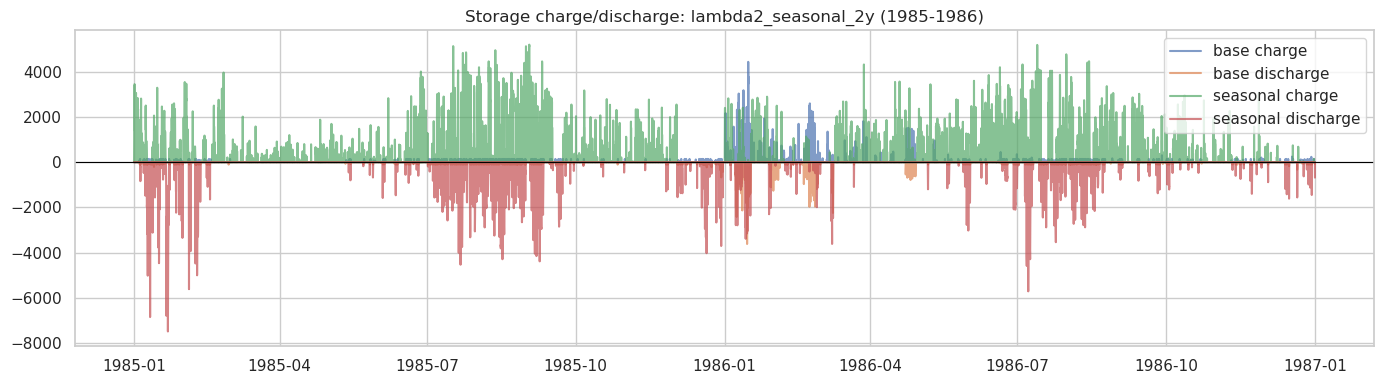

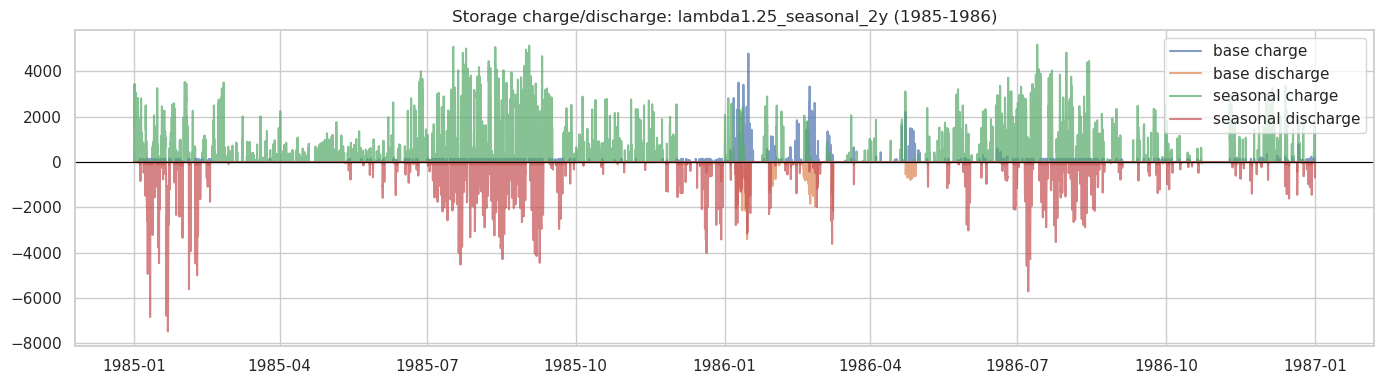

In [5]:
# --- Storage charge/discharge timeseries (full selected years) ---------
for run, data in run_data.items():
    label = LABELS.get(run, run)
    base_ch = total_ts(data["charge_base"], "charge")
    base_dis = total_ts(data["discharge_base"], "discharge")
    seas_ch = total_ts(data["charge_seasonal"], "charge")
    seas_dis = total_ts(data["discharge_seasonal"], "discharge")

    if base_ch.empty and base_dis.empty and seas_ch.empty and seas_dis.empty:
        continue

    fig, ax = plt.subplots(1, 1, figsize=(14,4))
    ax.plot(base_ch.index, base_ch.values, label="base charge", alpha=0.7)
    ax.plot(base_dis.index, -base_dis.values, label="base discharge", alpha=0.7)
    ax.plot(seas_ch.index, seas_ch.values, label="seasonal charge", alpha=0.7)
    ax.plot(seas_dis.index, -seas_dis.values, label="seasonal discharge", alpha=0.7)
    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.set_title(f"Storage charge/discharge: {label} ({min(YEARS)}-{max(YEARS)})")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


## C) Load shedding (time series + top buses)


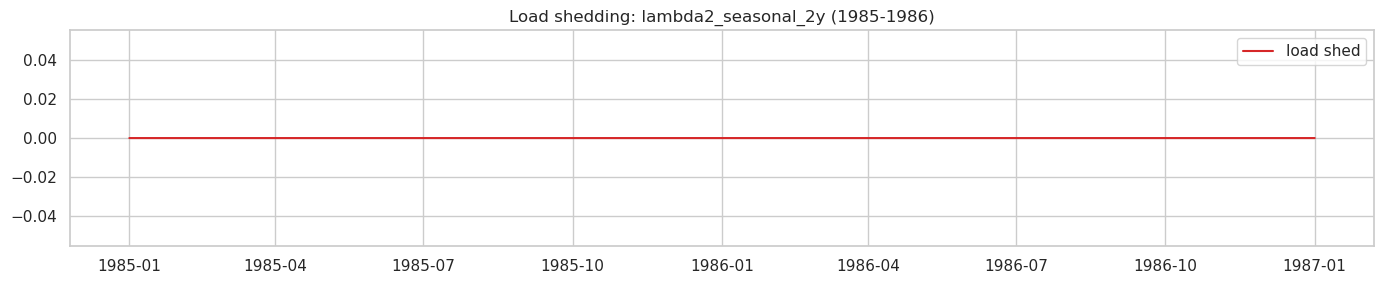

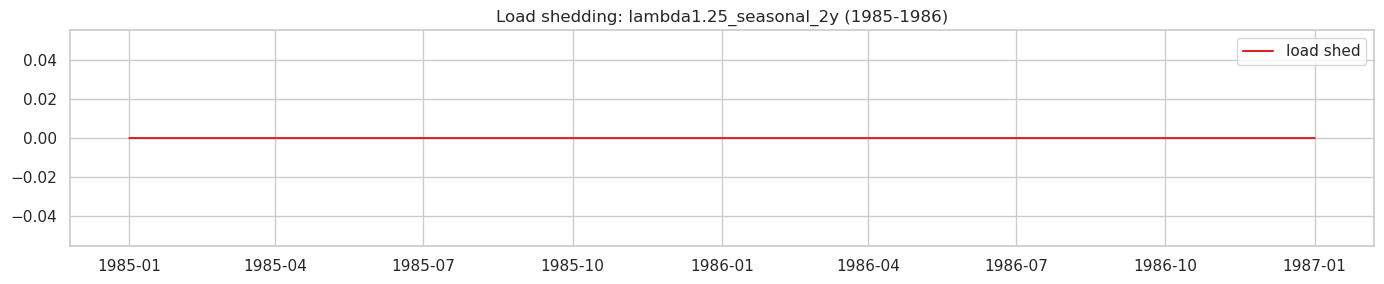

lambda2_seasonal_2y – top 15 shedding buses (all selected years)


,bus_id,load_shedding
0,37,0.0
1,38,0.0
2,39,0.0
3,40,0.0
4,41,0.0
5,42,0.0
6,43,0.0
7,44,0.0
8,45,0.0
9,46,0.0


lambda1.25_seasonal_2y – top 15 shedding buses (all selected years)


,bus_id,load_shedding
0,37,0.0
1,38,0.0
2,39,0.0
3,40,0.0
4,41,0.0
5,42,0.0
6,43,0.0
7,44,0.0
8,45,0.0
9,46,0.0


In [6]:
# --- Load shedding (full selected years) ----------------------------------
for run, data in run_data.items():
    label = LABELS.get(run, run)
    ls = total_ts(data["load_shed"], "load_shedding")
    if ls.empty:
        continue
    fig, ax = plt.subplots(1, 1, figsize=(14,3))
    ax.plot(ls.index, ls.values, label="load shed", color="tab:red")
    ax.set_title(f"Load shedding: {label} ({min(YEARS)}-{max(YEARS)})")
    ax.legend()
    plt.tight_layout()
    plt.show()

# Top shedding buses across all selected years
for run, data in run_data.items():
    label = LABELS.get(run, run)
    if data["load_shed"].empty:
        print(f"{label}: no load shedding data")
        continue
    ls_bus = data["load_shed"].groupby("bus_id")["load_shedding"].sum().sort_values(ascending=False).head(15)
    print(f"{label} – top 15 shedding buses (all selected years)")
    display(ls_bus.reset_index())


## D) Curtailment (wind + solar)


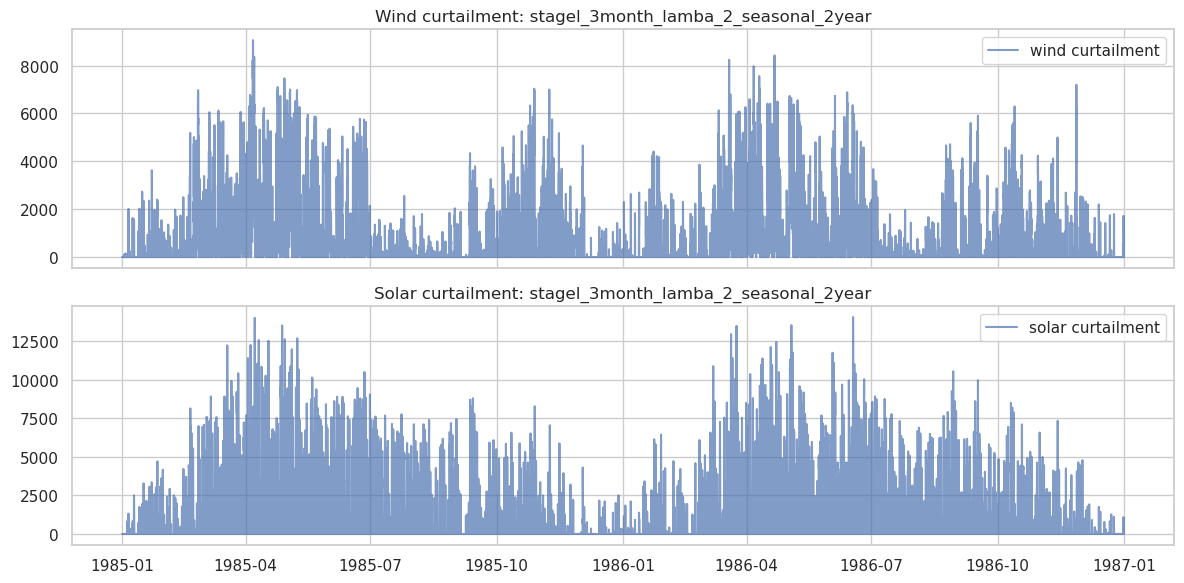

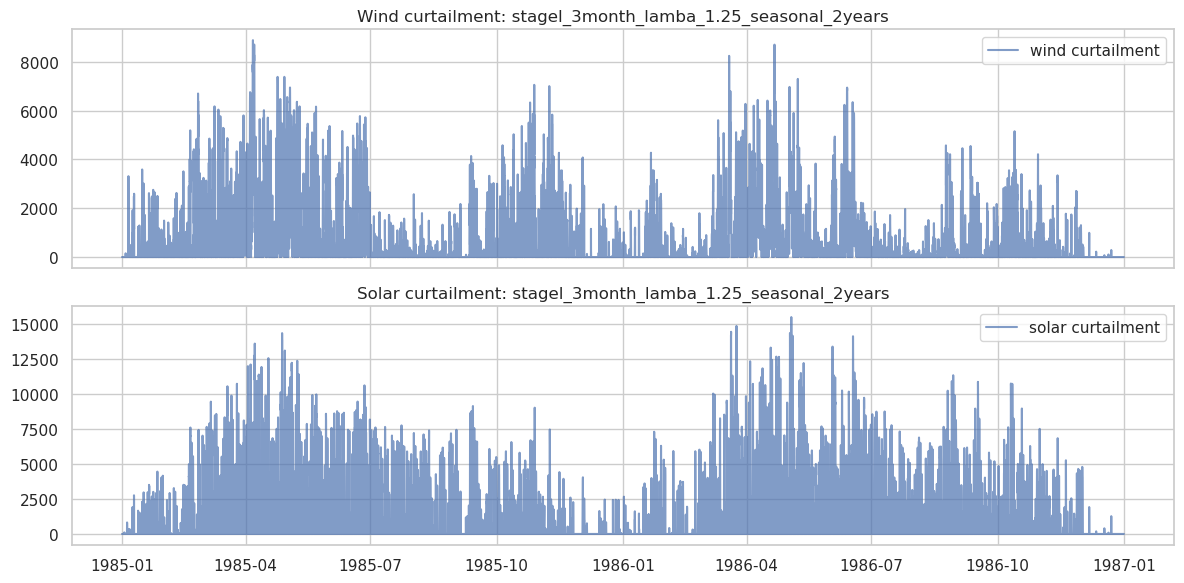

In [7]:

for label, data in run_data.items():
    wind = total_ts(data["wind_curt"], "wind_curtailment")
    solar = total_ts(data["solar_curt"], "solar_curtailment")

    fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=True)
    axes[0].plot(wind.index, wind.values, label="wind curtailment", alpha=0.7)
    axes[0].set_title(f"Wind curtailment: {label}")
    axes[0].legend()

    axes[1].plot(solar.index, solar.values, label="solar curtailment", alpha=0.7)
    axes[1].set_title(f"Solar curtailment: {label}")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


## E) Seasonal SOC stats + monthly seasonality


,run,soc_max_MWh,soc_min_MWh,soc_end_MWh
0,lambda2_seasonal_2y,3988171.85,3535345.41,3887931.29
1,lambda1.25_seasonal_2y,3989438.20,3533914.30,3887931.29


,run,year,soc_max_MWh,soc_min_MWh,soc_end_MWh
2,lambda1.25_seasonal_2y,1985,3989438.20,3593297.15,3593297.15
0,lambda2_seasonal_2y,1985,3988171.85,3593297.15,3593297.15
3,lambda1.25_seasonal_2y,1986,3895680.14,3533914.30,3887931.29
1,lambda2_seasonal_2y,1986,3933278.30,3535345.41,3887931.29


Daily net seasonal energy (MWh):


,lambda2_seasonal_2y,lambda1.25_seasonal_2y
timestamp,,
1985-01-01,31889.3,31967.6
1985-01-02,23151.2,23151.2
1985-01-03,22853.0,22786.7
1985-01-04,9240.9,9336.1
1985-01-05,23493.2,23386.2
...,...,...
1986-12-27,-81.8,-81.8
1986-12-28,-3076.3,-3076.3
1986-12-29,-3869.7,-3762.7


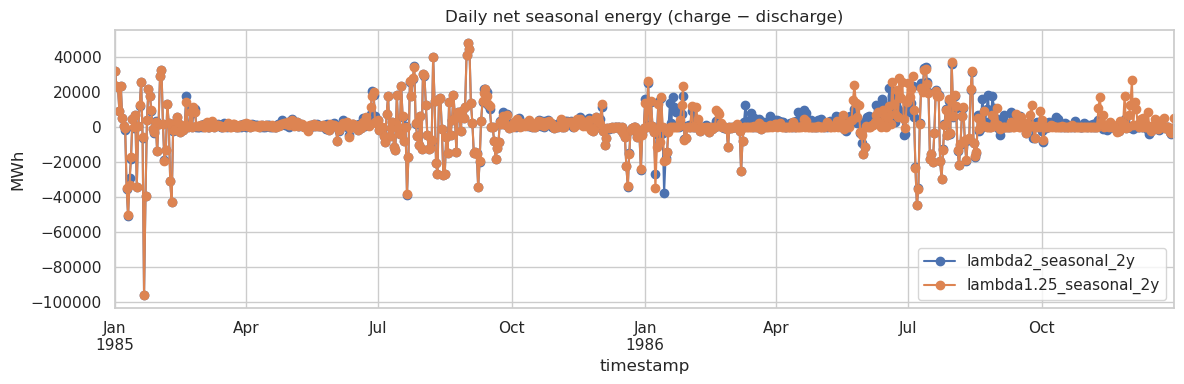

Daily mean seasonal SOC (MWh):


,lambda2_seasonal_2y,lambda1.25_seasonal_2y
1985-01-01,3904999.8,3905060.1
1985-01-02,3927655.3,3927723.0
1985-01-03,3947902.1,3947915.4
1985-01-04,3961853.2,3961865.9
1985-01-05,3973317.2,3973322.4
...,...,...
1986-12-27,3899109.5,3894350.9
1986-12-28,3897454.6,3892696.0
1986-12-29,3894124.8,3889371.4
1986-12-30,3888723.9,3883975.6


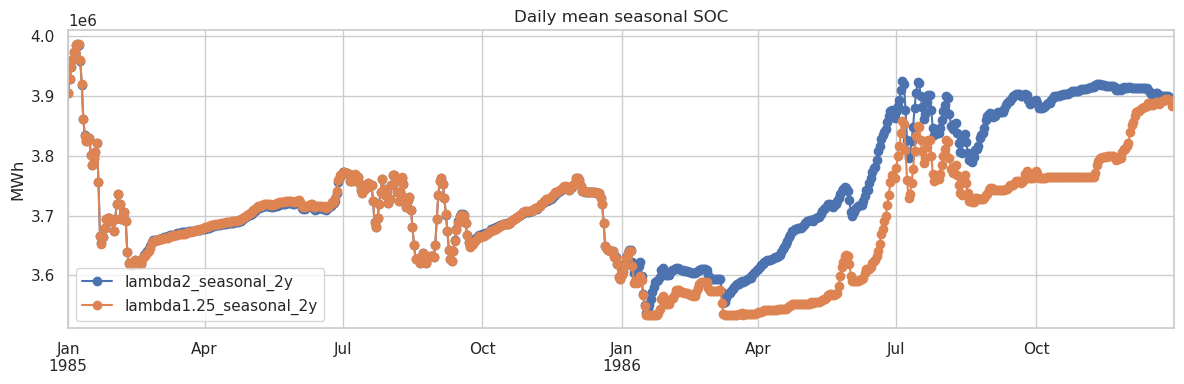

In [8]:
# --- Seasonal SOC summary ---------------------------------------------------
rows = []
for run, data in run_data.items():
    label = LABELS.get(run, run)
    soc = data["soc_seasonal"]
    if soc.empty:
        rows.append({"run": label, "soc_max_MWh": np.nan, "soc_min_MWh": np.nan, "soc_end_MWh": np.nan})
        continue
    rows.append({
        "run": label,
        "soc_max_MWh": float(soc.max()),
        "soc_min_MWh": float(soc.min()),
        "soc_end_MWh": float(soc.iloc[-1]),
    })

soc_df = pd.DataFrame(rows)
for c in soc_df.columns[1:]:
    soc_df[c] = soc_df[c].round(2)

display(soc_df)

# Per-year SOC summary
rows = []
for run, yearly in run_data_by_year.items():
    label = LABELS.get(run, run)
    for year, data in yearly.items():
        soc = data["soc_seasonal"]
        if soc.empty:
            rows.append({"run": label, "year": year, "soc_max_MWh": np.nan, "soc_min_MWh": np.nan, "soc_end_MWh": np.nan})
            continue
        rows.append({
            "run": label,
            "year": year,
            "soc_max_MWh": float(soc.max()),
            "soc_min_MWh": float(soc.min()),
            "soc_end_MWh": float(soc.iloc[-1]),
        })

soc_year_df = pd.DataFrame(rows)
if not soc_year_df.empty:
    for c in soc_year_df.columns[2:]:
        soc_year_df[c] = soc_year_df[c].round(2)
    display(soc_year_df.sort_values(["year", "run"]))

# Daily net energy + SOC

def daily_sum(series: pd.Series) -> pd.Series:
    if series is None or len(series) == 0:
        return pd.Series(dtype=float)
    s = series.copy()
    s.index = _strip_tz(s.index)
    return s.resample("D").sum()


def daily_mean(series: pd.Series) -> pd.Series:
    if series is None or len(series) == 0:
        return pd.Series(dtype=float)
    s = series.copy()
    s.index = _strip_tz(s.index)
    return s.resample("D").mean()

daily_net = {}
daily_soc = {}
for run, data in run_data.items():
    label = LABELS.get(run, run)
    seas_ch = total_ts(data["charge_seasonal"], "charge")
    seas_dis = total_ts(data["discharge_seasonal"], "discharge")
    net = seas_ch - seas_dis
    daily_net[label] = daily_sum(net)
    daily_soc[label] = daily_mean(data["soc_seasonal"])

daily_net_df = pd.DataFrame(daily_net).sort_index()
daily_soc_df = pd.DataFrame(daily_soc).sort_index()

print("Daily net seasonal energy (MWh):")
display(daily_net_df.round(1))

plot_net = daily_net_df.dropna(how="all", axis=1)
if not plot_net.empty:
    ax = plot_net.plot(figsize=(12,4), marker='o', title="Daily net seasonal energy (charge − discharge)")
    ax.set_ylabel("MWh")
    plt.tight_layout()
    plt.show()

print("Daily mean seasonal SOC (MWh):")
display(daily_soc_df.round(1))

plot_soc = daily_soc_df.dropna(how="all", axis=1)
if not plot_soc.empty:
    ax = plot_soc.plot(figsize=(12,4), marker='o', title="Daily mean seasonal SOC")
    ax.set_ylabel("MWh")
    plt.tight_layout()
    plt.show()


lambda2_seasonal_2y (1985) simultaneous hours: 18, days: 4


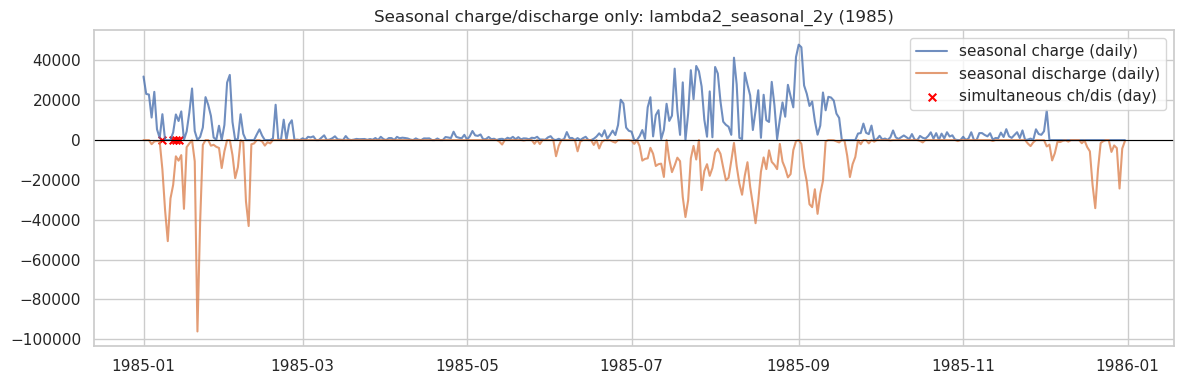

lambda2_seasonal_2y (1986) simultaneous hours: 101, days: 30


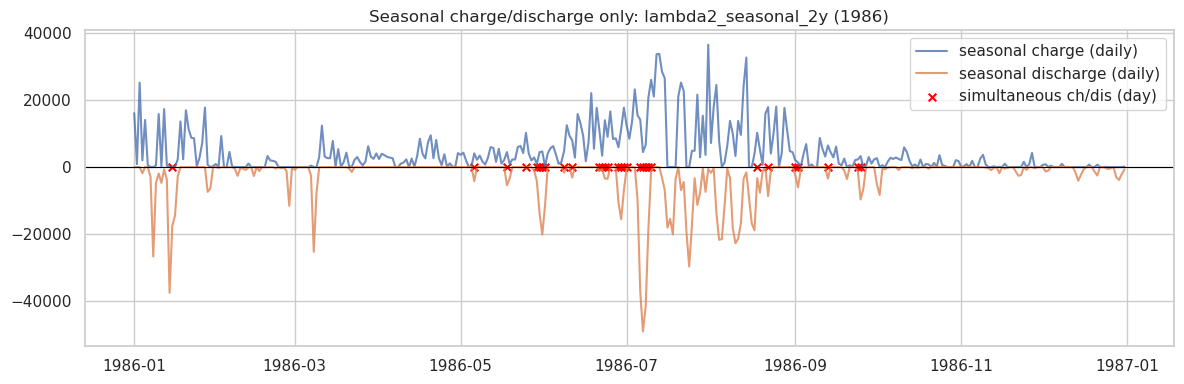

lambda1.25_seasonal_2y (1985) simultaneous hours: 20, days: 4


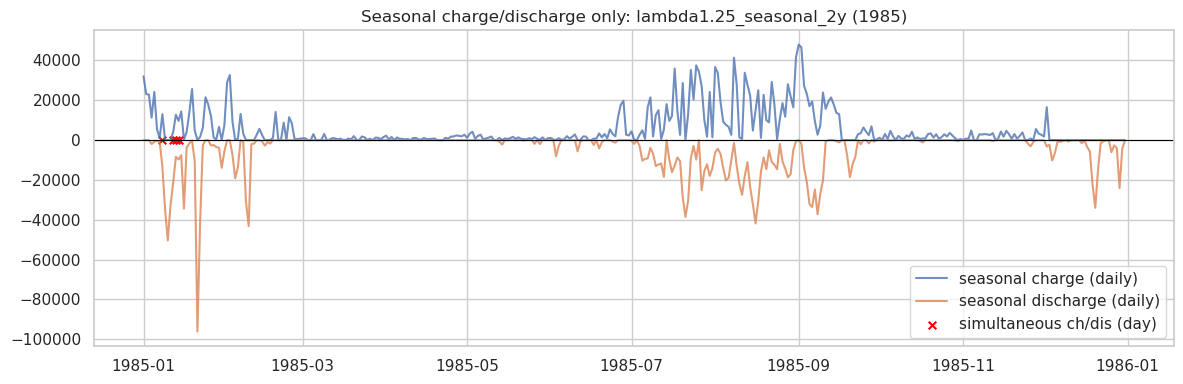

lambda1.25_seasonal_2y (1986) simultaneous hours: 115, days: 30


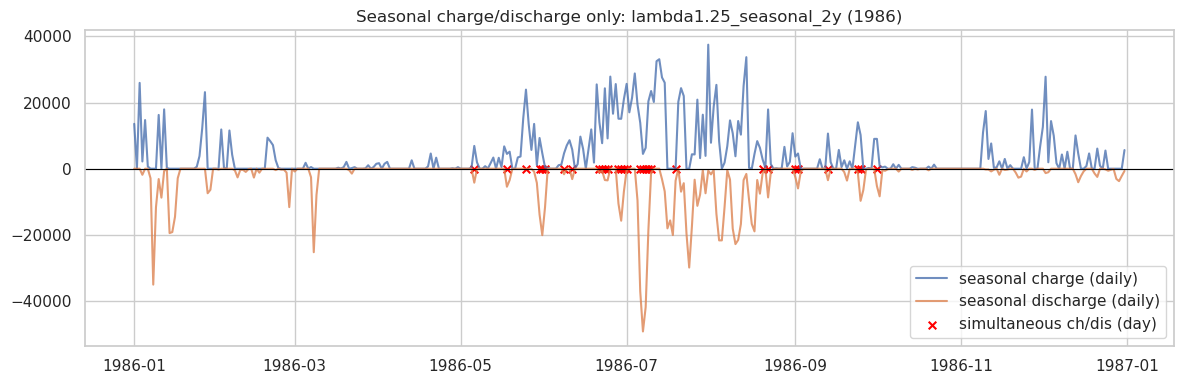

In [9]:
# --- Seasonal charge/discharge only + simultaneous events -------------------
SIMULT_TOL = 1e-6
for run, yearly in run_data_by_year.items():
    label = LABELS.get(run, run)
    for year, data in yearly.items():
        seas_ch = total_ts(data["charge_seasonal"], "charge")
        seas_dis = total_ts(data["discharge_seasonal"], "discharge")
        if seas_ch.empty and seas_dis.empty:
            continue

        # Daily aggregation for readability
        ch = seas_ch.copy()
        dis = seas_dis.copy()
        ch.index = _strip_tz(ch.index)
        dis.index = _strip_tz(dis.index)
        ch_d = ch.resample("D").sum()
        dis_d = dis.resample("D").sum()

        fig, ax = plt.subplots(figsize=(12,4))
        ax.plot(ch_d.index, ch_d.values, label="seasonal charge (daily)", alpha=0.8)
        ax.plot(dis_d.index, -dis_d.values, label="seasonal discharge (daily)", alpha=0.8)
        ax.axhline(0.0, color="black", linewidth=0.8)

        # Mark days with any simultaneous seasonal charge + discharge
        simult = (ch > SIMULT_TOL) & (dis > SIMULT_TOL)
        if simult.any():
            simult_days = simult.astype(int).resample("D").max()
            sim_days = simult_days[simult_days > 0].index
            ax.scatter(sim_days, [0.0]*len(sim_days), color="red", marker="x", s=30,
                       label="simultaneous ch/dis (day)")
            print(f"{label} ({year}) simultaneous hours: {int(simult.sum())}, days: {len(sim_days)}")
        else:
            print(f"{label} ({year}) simultaneous hours: 0, days: 0")

        ax.set_title(f"Seasonal charge/discharge only: {label} ({year})")
        ax.legend()
        plt.tight_layout()
        plt.show()


Using storage zones: ['A', 'B', 'D', 'E', 'G', 'J']


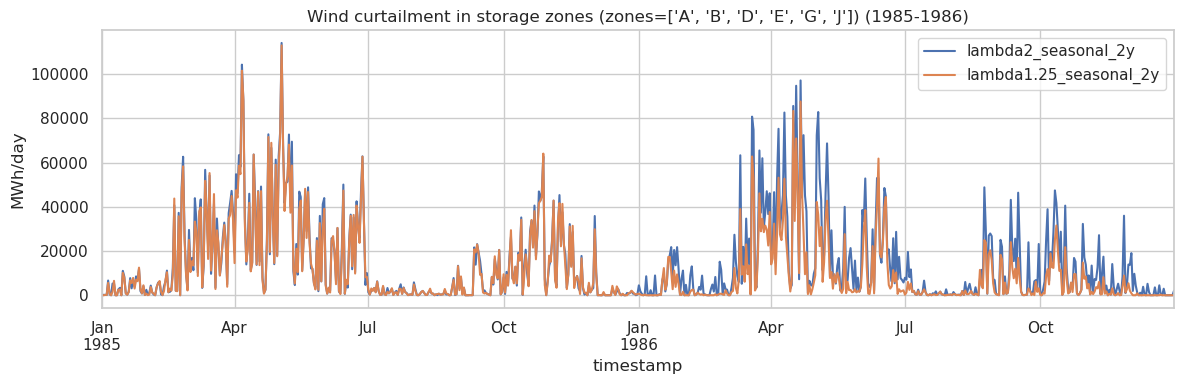

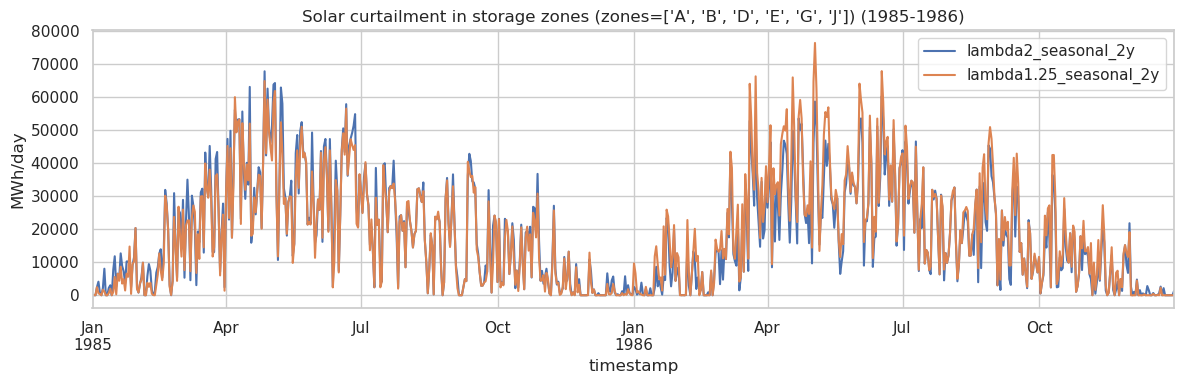

,run,wind_curt_MWh_in_storage_zones,solar_curt_MWh_in_storage_zones
0,lambda2_seasonal_2y,10465417.70,13441017.26
1,lambda1.25_seasonal_2y,8250261.95,13974281.56


In [10]:
# --- Curtailment comparison in storage zones -------------------------------
# If STORAGE_ZONES is None, infer from storage activity (seasonal first, then base)
STORAGE_ZONES = None  # e.g., ["A", "B"]


def infer_storage_zones(run_data: dict) -> list:
    zones = set()
    # Prefer seasonal zones if present, then base storage zones
    for run, data in run_data.items():
        for df in (data.get("charge_seasonal"), data.get("discharge_seasonal")):
            if df is not None and not df.empty and "zone" in df.columns:
                zones |= set(df["zone"].dropna().unique())
    if not zones:
        for run, data in run_data.items():
            for df in (data.get("charge_base"), data.get("discharge_base")):
                if df is not None and not df.empty and "zone" in df.columns:
                    zones |= set(df["zone"].dropna().unique())
    return sorted(zones)


zones = STORAGE_ZONES if STORAGE_ZONES is not None else infer_storage_zones(run_data)
print("Using storage zones:", zones)

if not zones:
    print("No storage zones detected; set STORAGE_ZONES manually.")
else:
    wind_daily = {}
    solar_daily = {}
    rows = []

    for run, data in run_data.items():
        label = LABELS.get(run, run)
        wind_df = data.get("wind_curt")
        solar_df = data.get("solar_curt")

        if wind_df is None or wind_df.empty:
            wind_ts = pd.Series(dtype=float)
        else:
            wind_ts = wind_df[wind_df["zone"].isin(zones)].groupby("timestamp")["wind_curtailment"].sum()
        if solar_df is None or solar_df.empty:
            solar_ts = pd.Series(dtype=float)
        else:
            solar_ts = solar_df[solar_df["zone"].isin(zones)].groupby("timestamp")["solar_curtailment"].sum()

        wind_ts.index = _strip_tz(wind_ts.index)
        solar_ts.index = _strip_tz(solar_ts.index)

        wind_d = wind_ts.resample("D").sum() if not wind_ts.empty else wind_ts
        solar_d = solar_ts.resample("D").sum() if not solar_ts.empty else solar_ts

        wind_daily[label] = wind_d
        solar_daily[label] = solar_d

        rows.append({
            "run": label,
            "wind_curt_MWh_in_storage_zones": float(pd.to_numeric(wind_ts, errors='coerce').fillna(0).sum()),
            "solar_curt_MWh_in_storage_zones": float(pd.to_numeric(solar_ts, errors='coerce').fillna(0).sum()),
        })

    # Plot wind comparison (all runs on one axis)
    wind_df = pd.DataFrame(wind_daily).sort_index()
    plot_wind = wind_df.dropna(how="all", axis=1)
    if not plot_wind.empty:
        ax = plot_wind.plot(figsize=(12,4), title=f"Wind curtailment in storage zones (zones={zones}) ({min(YEARS)}-{max(YEARS)})")
        ax.set_ylabel("MWh/day")
        plt.tight_layout()
        plt.show()

    # Plot solar comparison (all runs on one axis)
    solar_df = pd.DataFrame(solar_daily).sort_index()
    plot_solar = solar_df.dropna(how="all", axis=1)
    if not plot_solar.empty:
        ax = plot_solar.plot(figsize=(12,4), title=f"Solar curtailment in storage zones (zones={zones}) ({min(YEARS)}-{max(YEARS)})")
        ax.set_ylabel("MWh/day")
        plt.tight_layout()
        plt.show()

    # Summary table
    zone_curt_df = pd.DataFrame(rows)
    if not zone_curt_df.empty:
        for c in zone_curt_df.columns[1:]:
            zone_curt_df[c] = zone_curt_df[c].round(2)
        display(zone_curt_df)
